# Versao 11 - Classificacao Multiclasse Com LSTM Multitarefa

Este notebook treina exatamente a mesma arquitetura central da `versao10`. A diferenca experimental esta no que chega a ela depois do novo pre-processamento da `versao11`.

    ## Resultados Da Ultima Execucao Registrada

    Os artefatos atuais da `versao11` mostram:

    - melhor checkpoint na epoca `19`
    - validacao: `accuracy = 0.8851`, `macro-F1 = 0.8724`, `balanced accuracy = 0.8921`
    - teste: `accuracy = 0.9213`, `macro-F1 = 0.9155`, `balanced accuracy = 0.9225`
- variacao sobre a `versao10`: `-0.0160` em `accuracy`, `-0.0253` em `macro-F1` e `-0.0347` em `balanced accuracy`
    - classes mais dificeis no teste: classe `1` com `F1 = 0.0000`; classe `6` com `F1 = 0.0000`; classe `5` com `F1 = 0.5000`

    Interpretacao atual: a `versao11` testa se a `LSTM` aprende melhor quando o treino das classes de falha deixa de ser contaminado por observacoes cujo `state` ainda e ausente ou normal.

## O que fica igual em relacao a versao 10

- a rede principal continua sendo multitarefa;
- a entrada continua combinando `X_seq`, `X_tab`, `X_missing`, `X_frozen` e `source_id`;
- as cabecas auxiliares continuam prevendo `class` e `state` por observacao;
- os hiperparametros do treino permanecem os mesmos da `versao10`.

In [11]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao11" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from versao11.pipeline_v11 import (
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
    train_multitask_temporal_model,
    evaluate_predictions,
    export_evaluation_artifacts,
)

RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v11" / "classificacao_v11_segmentos_negativos"
LSTM_DIR = RUN_DIR / "lstm"
bundle = load_bundle(RUN_DIR / "bundle_v11.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

In [12]:
training_summary = train_multitask_temporal_model(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    X_train_missing=train_arrays["X_missing"],
    X_train_frozen=train_arrays["X_frozen"],
    y_train=train_arrays["y"],
    y_train_step_class=train_arrays["y_step_class"],
    y_train_step_state=train_arrays["y_step_state"],
    train_source_id=train_arrays["source_id"],
    X_val_seq=validation_arrays["X_seq"],
    X_val_tab=validation_arrays["X_tab"],
    X_val_missing=validation_arrays["X_missing"],
    X_val_frozen=validation_arrays["X_frozen"],
    y_val=validation_arrays["y"],
    y_val_step_class=validation_arrays["y_step_class"],
    y_val_step_state=validation_arrays["y_step_state"],
    val_source_id=validation_arrays["source_id"],
    output_dir=LSTM_DIR,
    class_labels=bundle.class_labels,
    observation_class_codes=bundle.observation_class_codes,
    observation_state_codes=bundle.observation_state_codes,
    source_vocab_size=len(bundle.source_mapping),
    hidden_size=160,
    num_layers=2,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.25,
    learning_rate=5e-4,
    weight_decay=1e-4,
    batch_size=64,
    epochs=55,
    patience=10,
    lambda_step_class=0.35,
    lambda_step_state=0.15,
    random_state=42,
)

training_summary

MultiTaskTrainingSummary(model_name='source_aware_multitask_temporal_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_history.csv', best_epoch=4, best_val_macro_f1=1.0, best_val_accuracy=1.0, best_val_balanced_accuracy=1.0)

In [13]:
best_model = load_multitask_temporal_model(training_summary.config_path)

validation_pred = predict_multitask_model_classes(
    best_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
test_pred = predict_multitask_model_classes(
    best_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

validation_eval = evaluate_predictions(
    validation_arrays["y"],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(test_eval, LSTM_DIR, "multitask_test")

pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_eval["accuracy"],
            "macro_f1": validation_eval["macro_f1"],
            "balanced_accuracy": validation_eval["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "balanced_accuracy": test_eval["balanced_accuracy"],
        },
    ]
)

,split,accuracy,macro_f1,balanced_accuracy
0,validation,1.0,1.0,1.0
1,test,1.0,1.0,1.0


,epoch,learning_rate,train_loss,train_instance_loss,train_step_class_loss,train_step_state_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
9,10,0.00050,0.040818,0.001230,0.001535,0.260338,0.992908,0.919239,0.996386,1.0,1.0,1.0
10,11,0.00025,0.063605,0.003960,0.002581,0.391613,0.992908,0.919239,0.996386,1.0,1.0,1.0
11,12,0.00025,0.014543,0.001328,0.001160,0.085396,0.992908,0.919239,0.996386,1.0,1.0,1.0
12,13,0.00025,0.024547,0.000920,0.000951,0.155296,0.992908,0.919239,0.996386,1.0,1.0,1.0
13,14,0.00025,0.006046,0.001980,0.001339,0.023986,0.992908,0.919239,0.996386,1.0,1.0,1.0


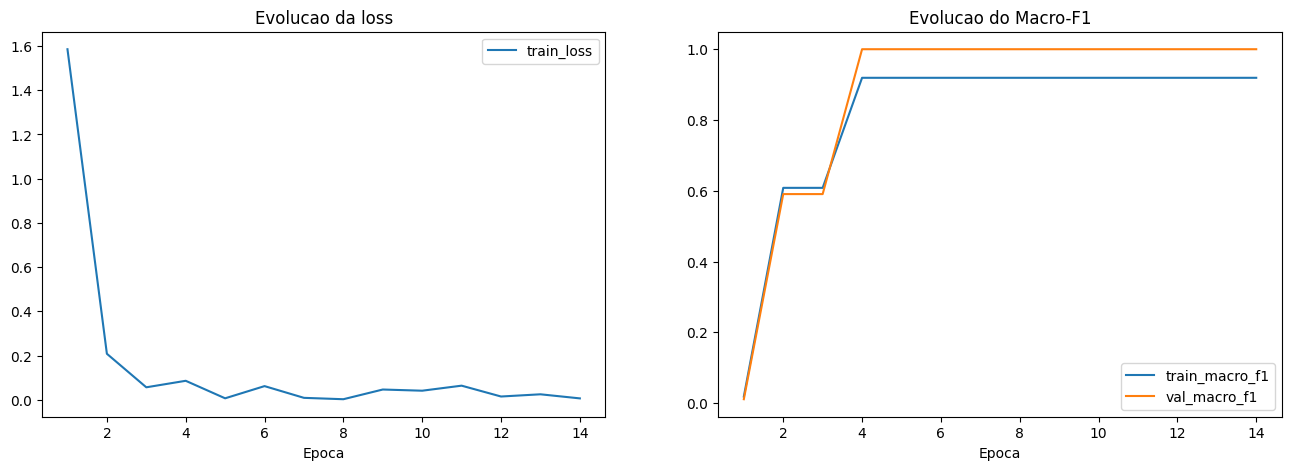

In [14]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].set_title("Evolucao da loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train_macro_f1")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Evolucao do Macro-F1")
axes[1].set_xlabel("Epoca")
axes[1].legend()
plt.show()

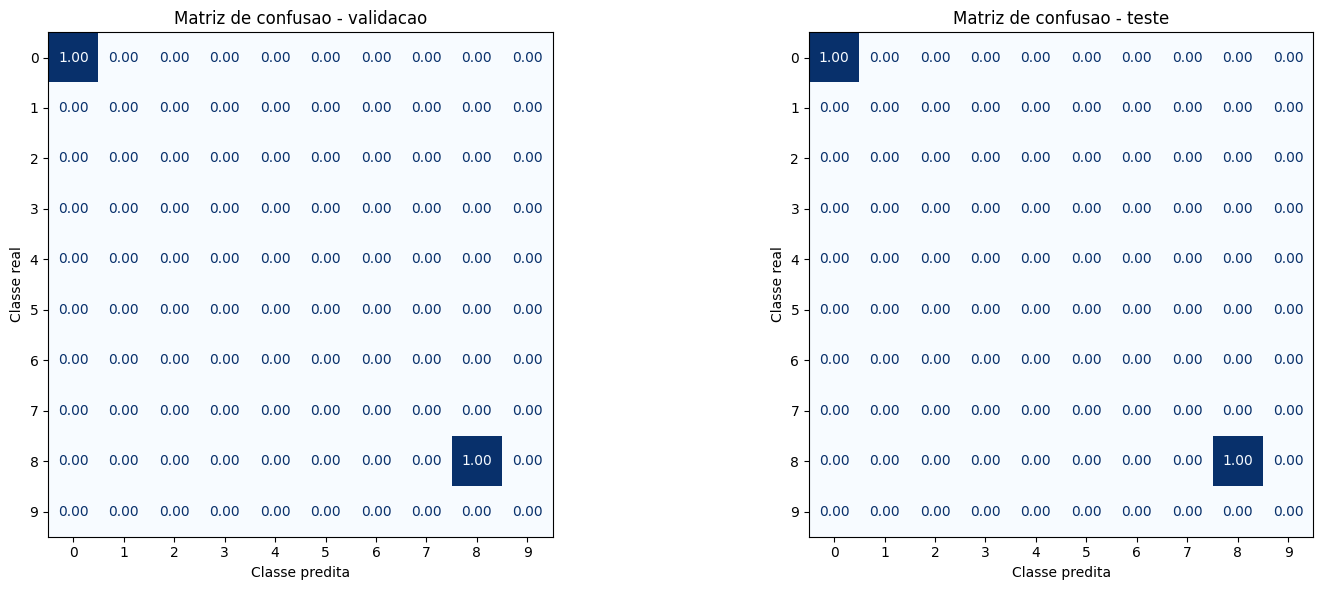

,label,precision,recall,f1-score,support
0,0,1.0,1.0,1.0,90.0
1,1,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0
5,5,0.0,0.0,0.0,0.0
6,6,0.0,0.0,0.0,0.0
7,7,0.0,0.0,0.0,0.0
8,8,1.0,1.0,1.0,2.0
9,9,0.0,0.0,0.0,0.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays["y"],
    validation_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - validacao",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - teste",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval["classification_report_df"])